# Solar Filament Segmentation Challenge 2026 -- ResNet50 BYOL Pretraining (Kaggle)

Domain-specific self-supervised pretraining of a 1-channel ResNet50 on the GONG
H-alpha corpus, via BYOL. Runs `scripts/pretrain_resnet/train_byol.py`, DDP-ready
for Kaggle's 2xT4. Design: `RESNET_PRETRAIN_PLAN.md`. Prerequisite: the
`halpha-preprocessed` Kaggle Dataset (built by `pretrain_gong_kaggle.ipynb`) added
as a notebook input, and a GPU accelerator (ideally 2xT4) enabled.

This is a **multi-session** run -- see section 6 below for the checklist to repeat
each session (mount latest checkpoint, run, version a new checkpoint dataset,
repeat).

### 0. Clone the repo

Requires `jp-pretraining-data-prep` (or wherever this lands) to already be pushed
to `origin`.

In [1]:
!ls

__notebook__.ipynb


In [2]:
!wget www.google.com

--2026-09-05 03:18:55--  http://www.google.com/
Resolving www.google.com (www.google.com)... 142.251.150.119, 142.251.153.119, 142.251.151.119, ...
Connecting to www.google.com (www.google.com)|142.251.150.119|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘index.html’

index.html              [ <=>                ]  81.46K  --.-KB/s    in 0s      

2026-09-05 03:18:55 (304 MB/s) - ‘index.html’ saved [83418]



In [3]:
!git clone -b jp-pretraining-data-prep https://github.com/jprakash-1/Solar-Filament-Segmentation.git


Cloning into 'Solar-Filament-Segmentation'...
remote: Enumerating objects: 466, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 466 (delta 56), reused 98 (delta 28), pack-reused 336 (from 1)
Receiving objects: 100% (466/466), 3.16 MiB | 30.83 MiB/s, done.
Resolving deltas: 100% (245/245), done.


In [4]:
%cd Solar-Filament-Segmentation
!ls


/kaggle/working/Solar-Filament-Segmentation
 data
 kaggle.md
 learning.md
 manifests
 memory.md
 pretrain_gong_colab.ipynb
 pretrain_gong_kaggle.ipynb
 PRETRAIN_PLAN.md
 pretrain_resnet_kaggle.ipynb
 README.md
 requirements.txt
 RESNET_PRETRAIN_PLAN.md
 scripts
'Solar Filament Segmentation Challenge 2026.code-workspace'


In [5]:
# !cp -r ../checkpoints/ ./

In [6]:
# re-run-safe: pick up any commits pushed after the kernel started
!git pull origin jp-pretraining-data-prep


From https://github.com/jprakash-1/Solar-Filament-Segmentation
 * branch            jp-pretraining-data-prep -> FETCH_HEAD
Already up to date.


### 1. Install dependencies

Kaggle's GPU images already ship torch/torchvision/pandas/tqdm -- only add what's
missing (`scipy`, for the augmentation's Gaussian blur; `segmentation_models_pytorch`
only if re-running `scripts/pretrain_resnet/model.py`'s `verify_stem_averaging`
check, not needed for training itself).

In [7]:
!pip install -q scipy


### 2. Mount the preprocessed corpus (+ a checkpoint dataset, on resume sessions)

In the Kaggle UI: **Add Input -> Datasets -> `halpha-preprocessed`** (first
session and every session), and on any session after the first, also add the
checkpoint dataset from the previous session's `/kaggle/working/checkpoints/`
version (see section 6).

Verify the actual mounted layout before trusting a path below -- it depends on how
the dataset was uploaded/zipped, and guessing wrong here just wastes a session:

In [8]:
!ls /kaggle/input/
!ls /kaggle/input/datasets/jainendraprakash/sun-image-halpha/gong_pretrain/ | head


datasets  models
20110101000014Mh.jpeg
20110101000034Lh.jpeg
20110101010014Mh.jpeg
20110101010034Lh.jpeg
20110101020014Mh.jpeg
20110101020034Lh.jpeg
20110101030014Mh.jpeg
20110101030034Lh.jpeg
20110101090014Th.jpeg
20110101110014Th.jpeg
ls: write error: Broken pipe


In [9]:
# Adjust these two if the listing above shows a different layout
# (e.g. files nested one directory deeper than expected).
IMAGES_DIR = "/kaggle/input/datasets/jainendraprakash/sun-image-halpha/gong_pretrain/"
MANIFEST = "/kaggle/input/halpha-preprocessed/manifest.csv"

# Point at the mounted checkpoint dataset's latest.pt on resume sessions; leave
# as None (the script's own --resume default) for the very first session.
RESUME_CKPT = "/kaggle/input/models/jainendra13901/pre-trained-halpha-sun-images/pytorch/default/2/checkpoints/latest.pt"  # e.g. "/kaggle/input/halpha-byol-ckpt/latest.pt"

# Optional: stop the run once val_loss hasn't improved for this many health
# checks (--health-check-every apart, so 10 * 5 = 50 epochs by default) --
# leave as None to always run the full --epochs on its cosine schedule.
EARLY_STOP_PATIENCE = 2 # e.g. 10


### 3. Smoke test before the real run

Small subset, single-process, 1 epoch -- catches a broken path or a shape bug in
under a minute, before committing a multi-hour session to it. Matches the
"verify against real data before trusting it at scale" standard the Stage 1/2
scripts were held to.

In [10]:
!python scripts/pretrain_resnet/train_byol.py \
    --images-dir $IMAGES_DIR --manifest $MANIFEST \
    --max-images 200 --epochs 1 --batch-size 16 --num-workers 2 \
    --checkpoint-out /kaggle/working/smoke_ckpt.pt --log-csv /kaggle/working/smoke_log.csv \
    --nn-grid-out /kaggle/working/smoke_nn.png


03:19:11 [INFO] world_size=1 device=cuda per_gpu_batch=16 base_lr=0.0125
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|███████████████████████████████████████| 97.8M/97.8M [00:00<00:00, 248MB/s]
03:19:13 [INFO] discovered 49243 images (49243 using fallback geometry, manifest covered 0)
03:19:13 [INFO] date-grouped split: 5 dates -> 4 train / 1 val dates (157 / 43 images)
epoch 0: 100%|████████████████████████████████████| 9/9 [00:05<00:00,  1.69it/s]
03:19:26 [INFO] epoch 0 | train_loss 3.6286 | val_loss 2.5954 | emb_std 0.0024 | tau 0.99600 | lr 1.25e-03 | no_improve 0


### 4. Full run: multi-GPU launch

`torchrun --nproc_per_node=2` for Kaggle's 2xT4 (drop to 1 if only a single GPU is
enabled). `NCCL_P2P_DISABLE=1` is the same T4-specific workaround
`PRETRAIN_PLAN.md` section 4.3 already had to apply. `--session-budget-seconds`
should stay well under the account's actual session cap (varies by verification
tier) -- the script self-stops with margin for the final checkpoint write, no need
to watch the clock.

In [11]:
RESUME_ARGS = f"--resume {RESUME_CKPT}" if RESUME_CKPT else ""
EARLY_STOP_ARGS = f"--early-stop-patience {EARLY_STOP_PATIENCE}" if EARLY_STOP_PATIENCE else ""

!NCCL_P2P_DISABLE=1 torchrun --nproc_per_node=2 scripts/pretrain_resnet/train_byol.py \
    --images-dir $IMAGES_DIR --manifest $MANIFEST \
    --epochs 150 --batch-size 128 --num-workers 4 \
    --checkpoint-out /kaggle/working/checkpoints/latest.pt \
    --best-checkpoint-out /kaggle/working/checkpoints/best.pt \
    --log-csv /kaggle/working/checkpoints/loss_log.csv \
    --nn-grid-out /kaggle/working/checkpoints/nn_grid.png \
    --session-budget-seconds 28800 --health-check-every 2 \
    {RESUME_ARGS} {EARLY_STOP_ARGS}


W0905 03:19:31.021000 98 torch/distributed/run.py:852] 
W0905 03:19:31.021000 98 torch/distributed/run.py:852] *****************************************
W0905 03:19:31.021000 98 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0905 03:19:31.021000 98 torch/distributed/run.py:852] *****************************************
03:19:35 [INFO] world_size=2 device=cuda:0 per_gpu_batch=128 base_lr=0.2000
03:19:39 [INFO] resumed from /kaggle/input/models/jainendra13901/pre-trained-halpha-sun-images/pytorch/default/2/checkpoints/latest.pt at epoch 60
03:19:40 [INFO] discovered 49243 images (49243 using fallback geometry, manifest covered 0)
03:19:40 [INFO] date-grouped split: 1878 dates -> 1803 train / 75 val dates (47239 / 2004 images)
03:19:40 [INFO] discovered 49243 images (49243 using fallback geometry, 

### 5. Sanity-check this session's output

Loss curve, plus the section 8 embedding-std collapse check and nearest-neighbor
visual check that `health_checks.py` already logged during training -- don't
trust the loss curve alone (BYOL can keep dropping loss while representations
collapse).

   epoch  train_loss  val_loss  embedding_std       tau        lr
0     60    0.496977  1.745719       0.005179  0.997398  0.143388
1     61    0.491286       NaN            NaN  0.997438  0.141356
2     62    0.500724  1.703720       0.006069  0.997479  0.139303


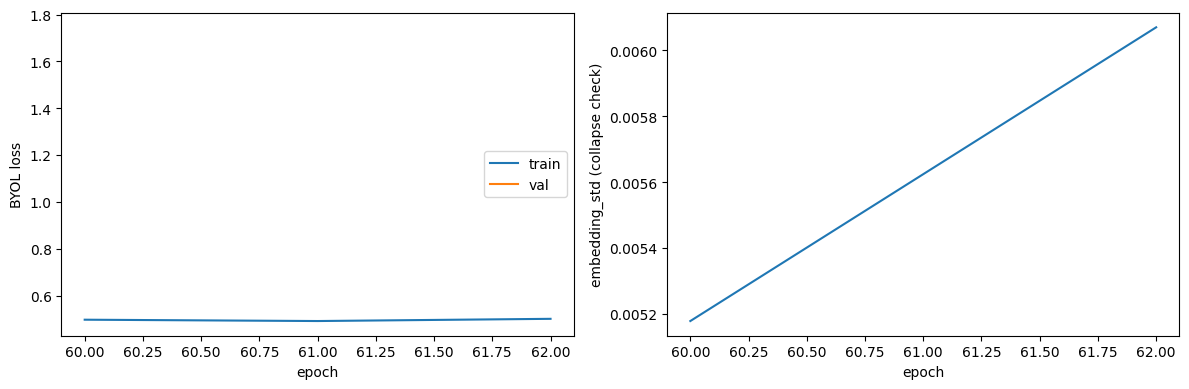

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

log = pd.read_csv("/kaggle/working/checkpoints/loss_log.csv")
print(log.tail())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(log["epoch"], log["train_loss"], label="train")
axes[0].plot(log["epoch"], log["val_loss"], label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BYOL loss"); axes[0].legend()

health = log.dropna(subset=["embedding_std"])
axes[1].plot(health["epoch"], health["embedding_std"])
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("embedding_std (collapse check)")
plt.tight_layout(); plt.show()


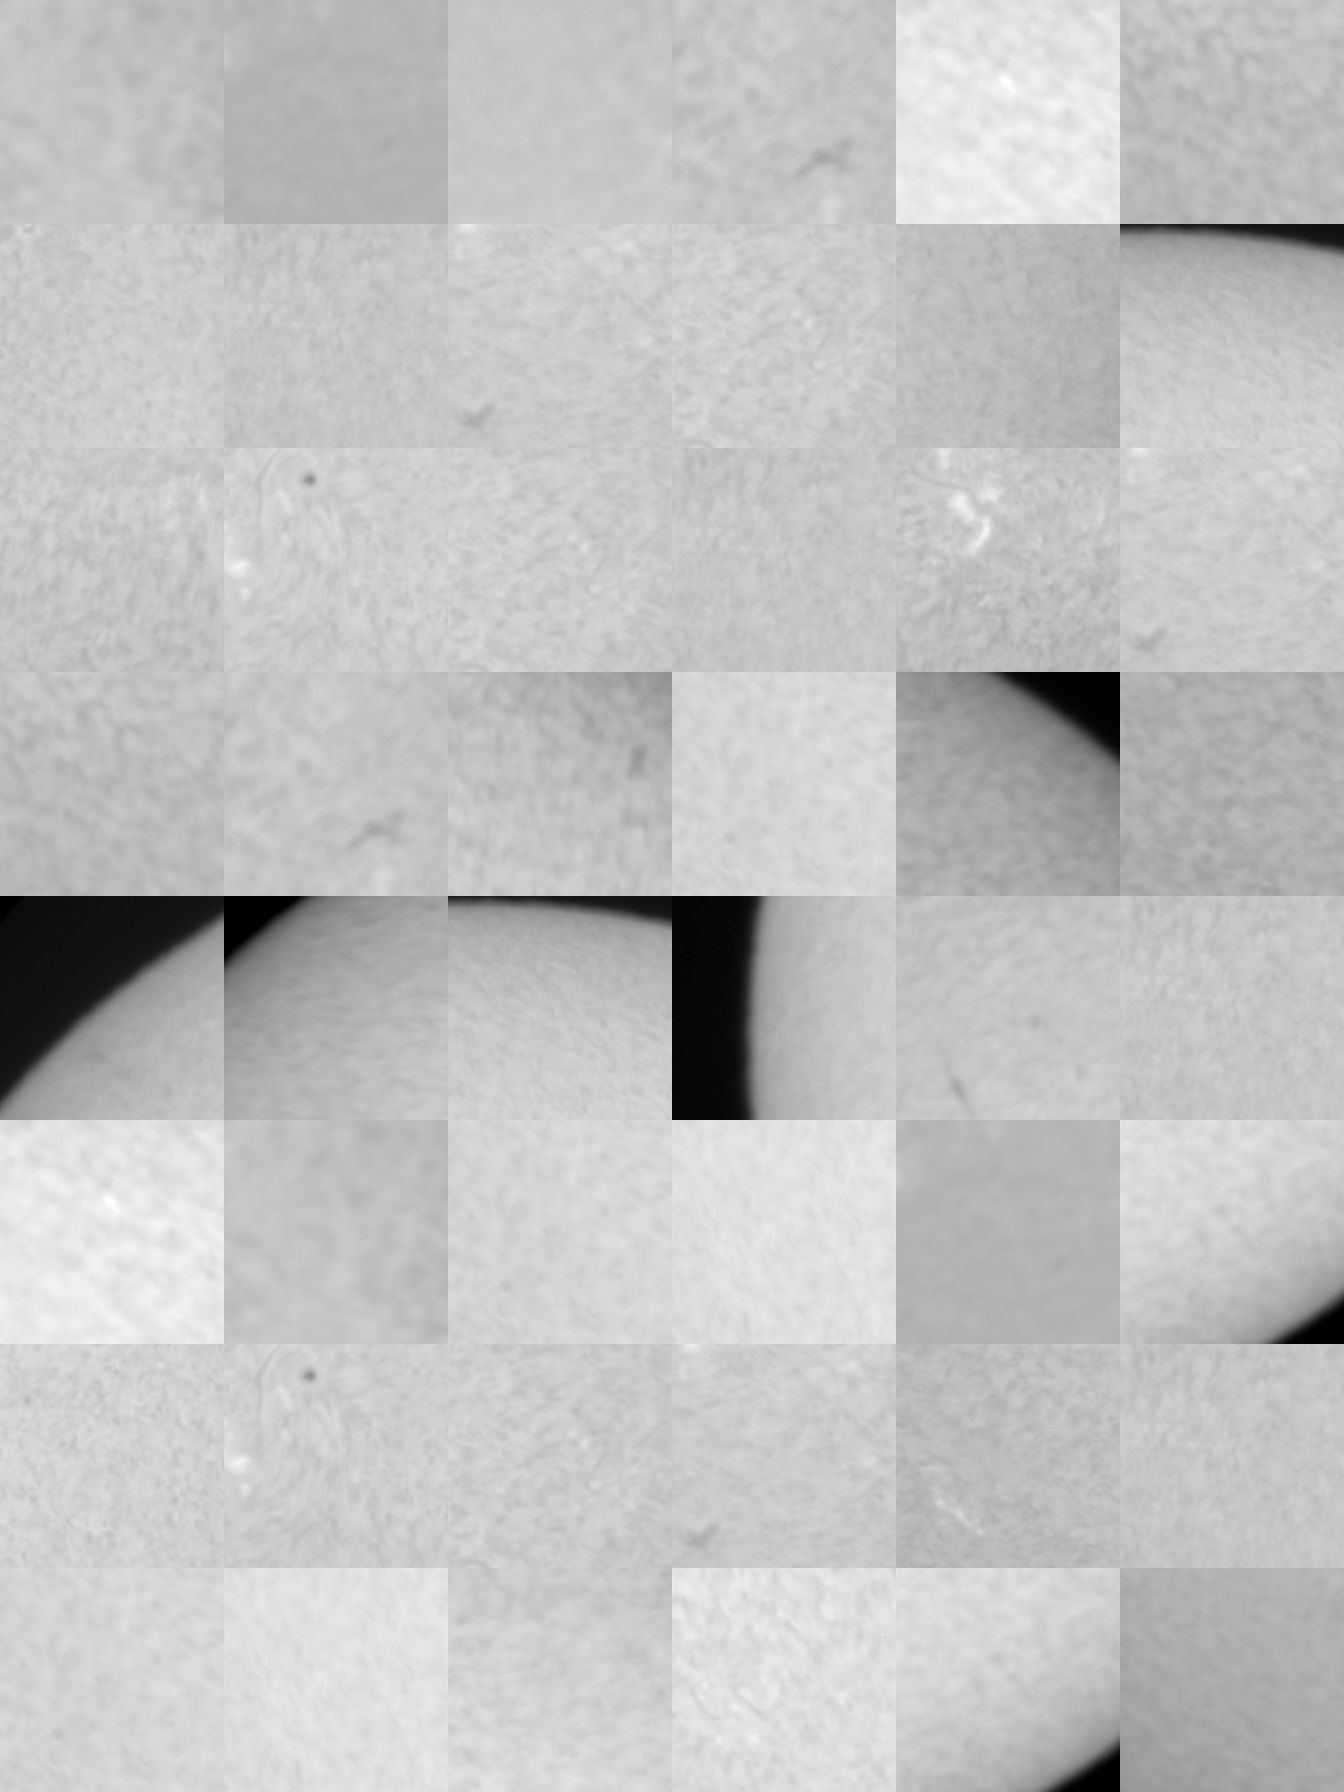

In [13]:
from PIL import Image
Image.open("/kaggle/working/checkpoints/nn_grid.png")


### 6. Session checklist (repeat each session)

1. Mount `halpha-preprocessed` and the latest `halpha-byol-ckpt` dataset (if any)
   as notebook inputs; set `RESUME_CKPT` above accordingly.
2. Run the smoke test (section 3), then the full launch cell (section 4).
3. The loop self-stops at `--session-budget-seconds`, checkpointing every epoch
   along the way -- an unplanned kill loses at most one epoch.
4. **New Dataset version** from `/kaggle/working/checkpoints/` -> this becomes
   next session's `halpha-byol-ckpt` input.
5. Run section 5's sanity check before ending the session -- catch a collapsed
   run early rather than after several more sessions of wasted compute.
6. Every few sessions: inspect `nn_grid.png` closely (section 5) -- confirm
   neighbors are astronomically similar, not random frames.

**Open items this run should help resolve** (`RESNET_PRETRAIN_PLAN.md` section
11): real images/sec on 2xT4 at this batch size (watch the tqdm it/s from
section 3/4 and back out a per-GPU throughput number), and whether the full
49K-image corpus vs. some thinning is the right call once real wall-clock/epoch
is known.